In [1]:
import requests
response=requests.get("https://api.coindcx.com/exchange/ticker")
print(response.status_code)

200


In [2]:
import requests

url="https://api.coindcx.com/exchange/ticker"

response=requests.get(url)

data=response.json()

print(data[0])

{'market': 'ACEINR', 'change_24_hour': '0.0', 'high': '11.07', 'low': '11.07', 'volume': '0.0', 'last_price': '11.0700000000', 'bid': '10.9000000000', 'ask': '11.4200000000', 'timestamp': 1780411026}


In [3]:
import requests

url="https://api.coindcx.com/exchange/ticker"

response=requests.get(url)

data=response.json()

coins=["BTCUSDT","ETHUSDT","DOGEUSDT"]

for item in data:

    if item["market"] in coins:

        print("Market:",item["market"])

        print("Price:",item["last_price"])

        print("----------------")

Market: ETHUSDT
Price: 1947.3
----------------
Market: BTCUSDT
Price: 68259.7
----------------
Market: DOGEUSDT
Price: 0.09648
----------------


In [4]:
#Live Updating Prices
import requests
import time

coins = ["BTCUSDT", "ETHUSDT", "DOGEUSDT"]

# Run only 5 times
for update in range(5):

    response = requests.get("https://api.coindcx.com/exchange/ticker")

    data = response.json()

    print("\nLIVE UPDATE", update + 1)

    print("-------")

    for item in data:

        if item["market"] in coins:

            print(item["market"],":",item["last_price"])

    # Wait 5 seconds
    time.sleep(5)

print("\nProgram Stopped After 5 Updates")


LIVE UPDATE 1
-------
ETHUSDT : 1947.3
BTCUSDT : 68259.7
DOGEUSDT : 0.09648

LIVE UPDATE 2
-------
ETHUSDT : 1947.3
BTCUSDT : 68259.7
DOGEUSDT : 0.09648

LIVE UPDATE 3
-------
ETHUSDT : 1947
BTCUSDT : 68253.2
DOGEUSDT : 0.09647

LIVE UPDATE 4
-------
ETHUSDT : 1945.75
BTCUSDT : 68245.2
DOGEUSDT : 0.0964

LIVE UPDATE 5
-------
ETHUSDT : 1945.21
BTCUSDT : 68242
DOGEUSDT : 0.0964

Program Stopped After 5 Updates


In [5]:
#Saving Data into CSV
import requests
import pandas as pd
import time
from datetime import datetime

coins = ["BTCUSDT", "ETHUSDT", "DOGEUSDT"]

# Save only 5 times
for update in range(5):

    response = requests.get(
        "https://api.coindcx.com/exchange/ticker"
    )

    data = response.json()

    records = []

    for item in data:

        if item["market"] in coins:

            records.append({

                "Time":
                datetime.now(),

                "Market":
                item["market"],

                "Price":
                float(
                    item["last_price"]
                )

            })

    new_df = pd.DataFrame(records)

    try:

        old_df = pd.read_csv(
            "prices.csv"
        )

        final_df = pd.concat(
            [old_df, new_df],
            ignore_index=True
        )

    except:

        final_df = new_df

    final_df.to_csv(
        "prices.csv",
        index=False
    )

    print(
        "Saved Update",
        update + 1
    )

    time.sleep(5)

print("\nCSV Saving Stopped After 5 Updates")

Saved Update 1
Saved Update 2
Saved Update 3
Saved Update 4
Saved Update 5

CSV Saving Stopped After 5 Updates


In [6]:
#Validation and Error Handling
import requests
try:
    response=requests.get(
        "https://api.coindcx.com/exchange/ticker"
    )

    print(
        "Status Code:",
        response.status_code
    )

    if response.status_code==200:

        data=response.json()

        print(
            "API Connected Successfully"
        )

        print(
            "Total Markets:",
            len(data)
        )

    else:

        print(
            "API Error"
        )

except Exception as e:

    print(e)

Status Code: 200
API Connected Successfully
Total Markets: 1046


In [7]:
# Price Alert System
import requests
response=requests.get("https://api.coindcx.com/exchange/ticker")

data=response.json()

for item in data:

    if item["market"]=="BTCUSDT":

        price=float(
            item["last_price"]
        )

        print(
            "Current BTC Price:",
            price
        )

        if price>80000:

            print(
                "ALERT: BTC above 80000"
            )

        else:

            print(
                "BTC below alert level"
            )

Current BTC Price: 68230.1
BTC below alert level


In [8]:
#Order Book API
import requests

url="https://public.coindcx.com/market_data/orderbook?pair=B-BTC_USDT"

response=requests.get(url)

data=response.json()

print("Top Bids:\n")

count=0

for price,quantity in data["bids"].items():

    print(
        "Price:",
        price,
        "Quantity:",
        quantity
    )

    count+=1

    if count==5:
        break

Top Bids:

Price: 68218 Quantity: 0.02045256
Price: 68224 Quantity: 0.322789
Price: 68230 Quantity: 0.39293551
Price: 68233 Quantity: 0.00170399
Price: 68234 Quantity: 0.46888542


In [9]:
#Candlestick Data
import requests
import pandas as pd

url="https://public.coindcx.com/market_data/candles?pair=B-BTC_USDT&interval=1m"

response=requests.get(url)

data=response.json()

df=pd.DataFrame(data)

print(df.head())

        open       high        low    volume      close           time
0  120549.99  120595.99  120549.99   5.38755  120595.98  1752788940000
1  120461.58  120550.00  120456.17   8.18574  120549.99  1752788880000
2  120501.94  120532.01  120461.32  12.54084  120461.58  1752788820000
3  120731.01  120732.99  120501.94  10.48228  120501.94  1752788760000
4  120605.58  120761.09  120605.57  19.79930  120731.01  1752788700000


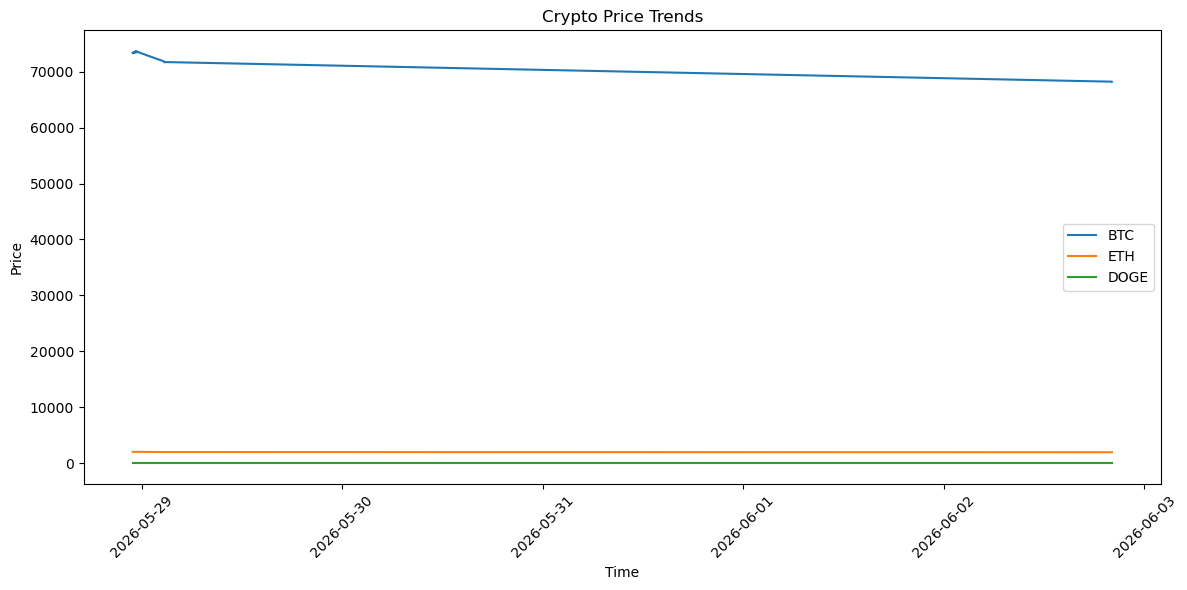

In [10]:
#Multi line chart
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("prices.csv")

df["Time"]=pd.to_datetime(
    df["Time"]
)

btc=df[
    df["Market"]=="BTCUSDT"
]

eth=df[
    df["Market"]=="ETHUSDT"
]

doge=df[
    df["Market"]=="DOGEUSDT"
]

plt.figure(figsize=(12,6))

plt.plot(
    btc["Time"],
    btc["Price"],
    label="BTC"
)

plt.plot(
    eth["Time"],
    eth["Price"],
    label="ETH"
)

plt.plot(
    doge["Time"],
    doge["Price"],
    label="DOGE"
)

plt.xticks(rotation=45)

plt.xlabel("Time")

plt.ylabel("Price")

plt.title("Crypto Price Trends")

plt.legend()

plt.tight_layout()

plt.show()

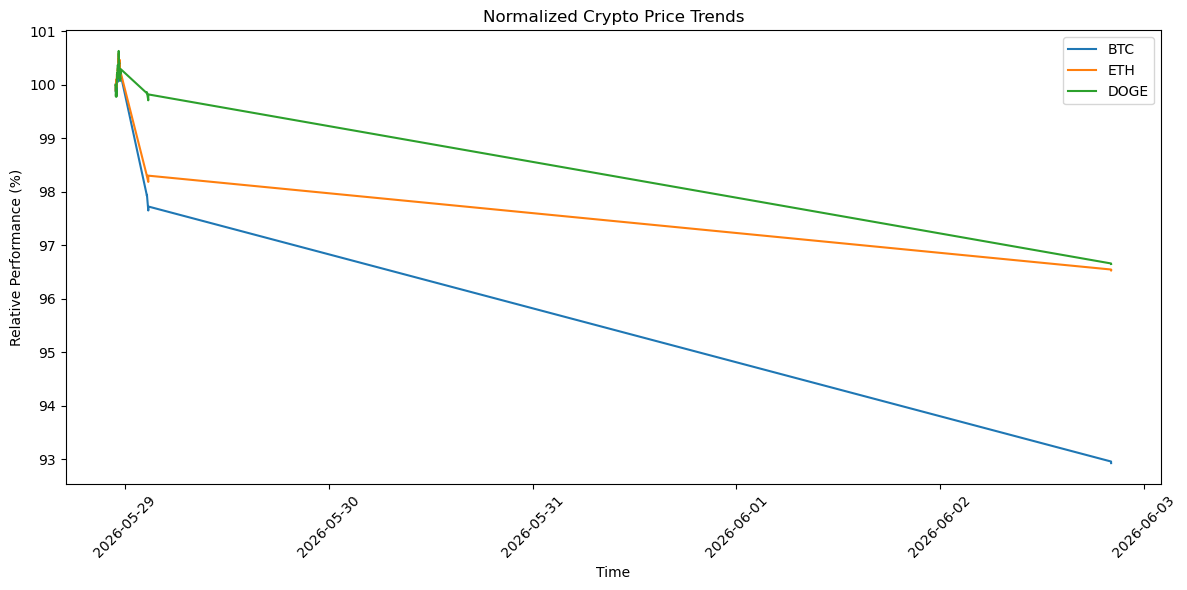

In [11]:
#Normalized comparison chart
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("prices.csv")

df["Time"] = pd.to_datetime(df["Time"])

btc = df[df["Market"]=="BTCUSDT"].copy()
eth = df[df["Market"]=="ETHUSDT"].copy()
doge = df[df["Market"]=="DOGEUSDT"].copy()

# Normalize to first value = 100
btc["Normalized"] = btc["Price"] / btc["Price"].iloc[0] * 100
eth["Normalized"] = eth["Price"] / eth["Price"].iloc[0] * 100
doge["Normalized"] = doge["Price"] / doge["Price"].iloc[0] * 100

plt.figure(figsize=(12,6))

plt.plot(btc["Time"], btc["Normalized"], label="BTC")
plt.plot(eth["Time"], eth["Normalized"], label="ETH")
plt.plot(doge["Time"], doge["Normalized"], label="DOGE")

plt.title("Normalized Crypto Price Trends")
plt.xlabel("Time")
plt.ylabel("Relative Performance (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

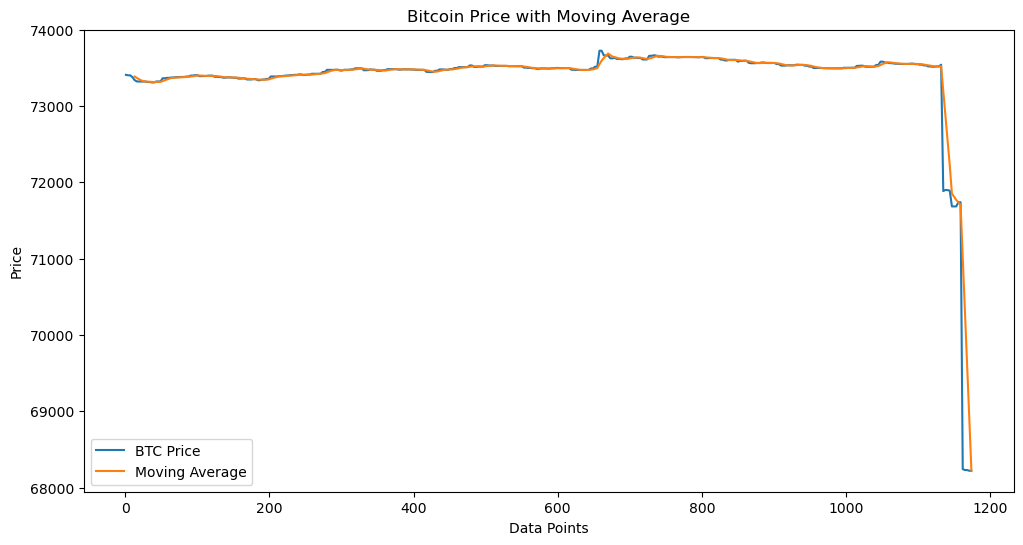

In [12]:
#Moving Average Analysis
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("prices.csv")

btc=df[
    df["Market"]=="BTCUSDT"
].copy()

btc["MovingAverage"]=(btc["Price"].rolling(window=5).mean())

plt.figure(figsize=(12,6))

plt.plot(btc.index,btc["Price"],label="BTC Price")

plt.plot(btc.index,btc["MovingAverage"],label="Moving Average")

plt.xlabel("Data Points")

plt.ylabel("Price")

plt.title("Bitcoin Price with Moving Average")

plt.legend()

plt.show()